In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re


import os
import itertools
import cv2
import datetime
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,  BatchNormalization, Activation, Dropout  ,Input,Concatenate,GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras import regularizers,layers, models ,optimizers

import splitfolders
from tensorflow.keras.applications import DenseNet121

from sklearn.utils import class_weight
from collections import Counter

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger, ReduceLROnPlateau,TensorBoard

import warnings
warnings.filterwarnings("ignore")




In [2]:



input_folder = r"C:\My Folders\Final Year Project\Classifir_image"
output_folder = r"C:\My Folders\Final Year Project\Classifir_image_Splits"

splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.7, 0.15, 0.15)  # 70% train, 15% val, 15% test
)

print("Dataset Split Completed ✅")

Dataset Split Completed ✅


In [2]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)



In [3]:
input_image_size = (224 , 224)  # DensNet121  default input size
batch_size = 16

In [4]:
# load dataset

# Load training dataset without preprocessing
train_ds = datagen.flow_from_directory(
    r"C:\My Folders\Final Year Project\Classifir_image_Splits\train",
    
    
    batch_size=batch_size,
    target_size=input_image_size,
    class_mode='binary',
    shuffle=True
    
    
    
)

# Load validation dataset without preprocessing
val_ds = datagen.flow_from_directory(
    r"C:\My Folders\Final Year Project\Classifir_image_Splits\val",
    
    
    batch_size=batch_size,
    target_size=input_image_size,
    class_mode='binary',
    
   
)

# Load test dataset without preprocessing
test_ds =datagen.flow_from_directory(
    r"C:\My Folders\Final Year Project\Classifir_image_Splits\test",
    
    batch_size=batch_size,
    target_size=input_image_size,
    class_mode='binary',
    shuffle=False,
    
    
)

Found 11780 images belonging to 2 classes.
Found 2524 images belonging to 2 classes.
Found 2525 images belonging to 2 classes.


In [5]:
print("Train Images:", train_ds.samples)
print("Validation Images:", val_ds.samples)
print("Test Images:", test_ds.samples)

Train Images: 11780
Validation Images: 2524
Test Images: 2525


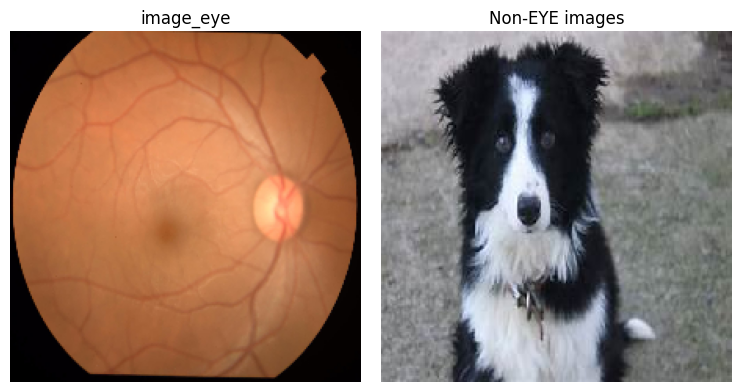

In [6]:
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

dataset_path = r"C:\My Folders\Final Year Project\Classifir_image_Splits\train" # Change if needed

class_names = os.listdir(dataset_path)

plt.figure(figsize=(15, 15))

for i, class_name in enumerate(class_names):
    
    class_path = os.path.join(dataset_path, class_name)
    
    # Get random image from that class folder
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    
    img = image.load_img(img_path, target_size=(224,224))
    
    plt.subplot(4, 4, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
num_classes = len(train_ds.class_indices)
print("Number of classes:", num_classes)

Number of classes: 2


In [8]:
train_ds.class_indices

{'Non-EYE images': 0, 'image_eye': 1}

In [9]:
dataset_path = r"C:\My Folders\Final Year Project\Classifir_image"  # Change to your dataset path

total_images = 0
class_counts = {}

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        class_counts[class_name] = num_images
        total_images += num_images

print("Total Images:", total_images)
print("\nImages Per Class:")
for k, v in class_counts.items():
    print(f"{k} : {v}")

Total Images: 16829

Images Per Class:
image_eye : 8560
Non-EYE images : 8269


In [10]:
# ===================== CALLBACKS =====================
log_dir = "Classifer/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
Callback = (TensorBoard(log_dir="classifir",histogram_freq=1),
 ModelCheckpoint(
    "Classifir_image_model.keras",
    monitor='val_loss',
    save_best_only=True,
    mode='min'
),
 CSVLogger("Classifir_image_training_Eye.csv", append=True),
ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
))


Early_stop = EarlyStopping(
    patience=8,
    restore_best_weights=True
)
Csv=CSVLogger("Classifir_image_training_Eye1.csv", append=True)




In [11]:

# ===================== MODEL CONSTRUCTION =====================

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# -------- PHASE 1: FEATURE EXTRACTION --------
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),   # slightly reduced for imbalance
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ===================== TRAIN PHASE 1 =====================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=[Csv])

# ===================== PHASE 2: FINE-TUNING =====================

base_model.trainable = True

# Keep BatchNorm frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Fine-tune last dense block
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics = [
    'accuracy',
    tf.keras.metrics.Precision(top_k=1, name='precision'),
    tf.keras.metrics.Recall(top_k=1, name='recall')]
)

# ===================== TRAIN PHASE 2 =====================
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=Callback)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet121 (Functional)    (None, 7, 7, 1024)        7037504   
                                                                 
 global_average_pooling2d (G  (None, 1024)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 512)               524800    
                                                                 
 batch_normalization (BatchN  (None, 512)              2048      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                 5

Final shape: (1, 224, 224, 3)


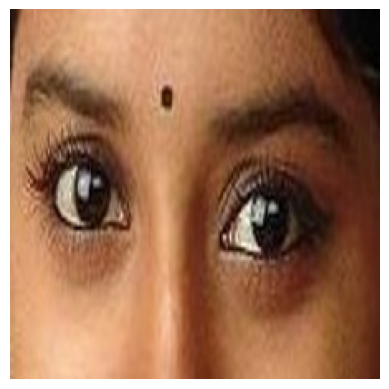

In [19]:
from PIL import Image
import numpy as np
from IPython.display import display

img = Image.open(r"C:\My Folders\Final Year Project\Eye_image_Split\test\Healthy_Eye1\STRABISMUS_normal (21).jpg").convert("RGB")
img = img.resize((224, 224))

img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

print("Final shape:", img_array.shape)
import matplotlib.pyplot as plt

plt.imshow(img_array[0])
plt.axis("off")
plt.show()

In [ ]:
plt